# EDA with Titanic Dataset

In [65]:
import seaborn as sns
import pandas as pd

In [66]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [67]:
df = sns.load_dataset("titanic")

In [68]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [69]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [70]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# EDA 

<Axes: xlabel='survived', ylabel='count'>

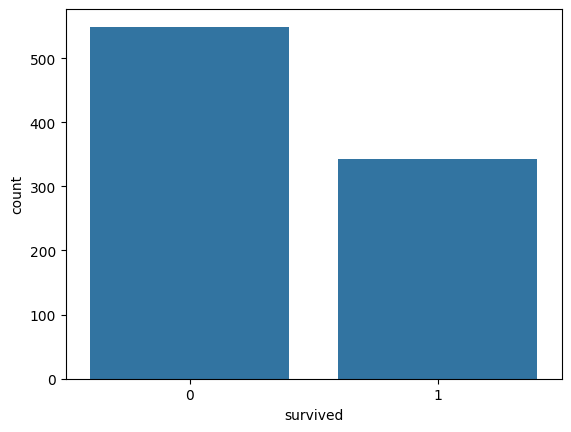

In [71]:
sns.countplot(x= "survived", data=df)

In [72]:
df["alive"].value_counts()


alive
no     549
yes    342
Name: count, dtype: int64

In [73]:
df["alive"].value_counts(normalize=True)

alive
no     0.616162
yes    0.383838
Name: proportion, dtype: float64

In [74]:
result = df["alive"].value_counts(normalize=True)

In [75]:
result["yes"]*100

np.float64(38.38383838383838)

In [76]:
"{:.0%}".format(result["yes"])

'38%'

<Axes: xlabel='alive', ylabel='count'>

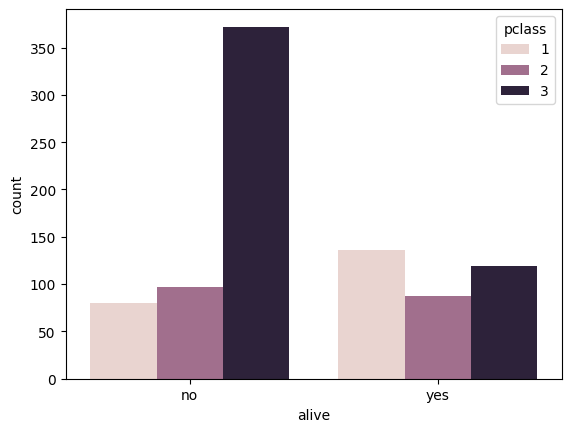

In [77]:
sns.countplot(x="alive", data=df, hue="pclass")

<Axes: xlabel='alive', ylabel='count'>

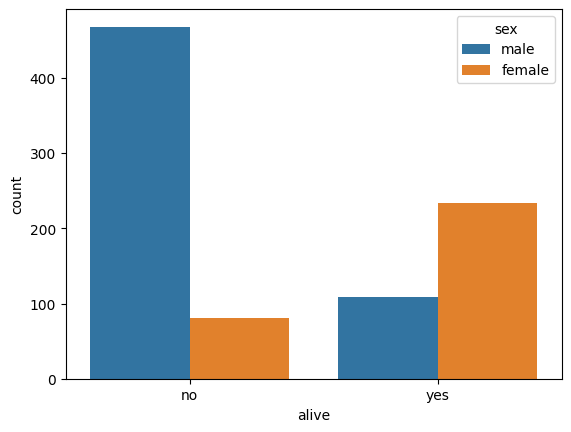

In [78]:
sns.countplot(x="alive", data=df, hue= "sex")

<Axes: xlabel='age', ylabel='Count'>

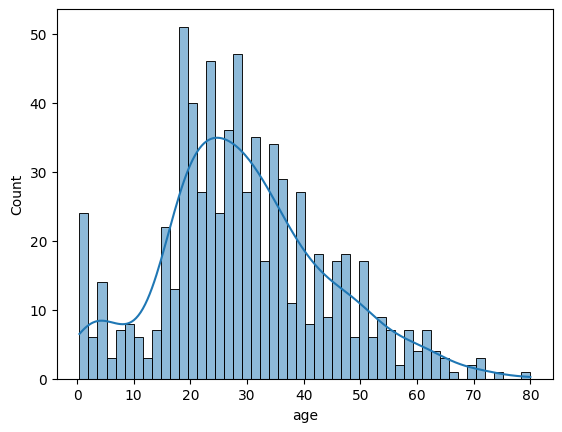

In [79]:
sns.histplot(x="age", data=df, bins=50, kde=True)

<Axes: xlabel='survived', ylabel='age'>

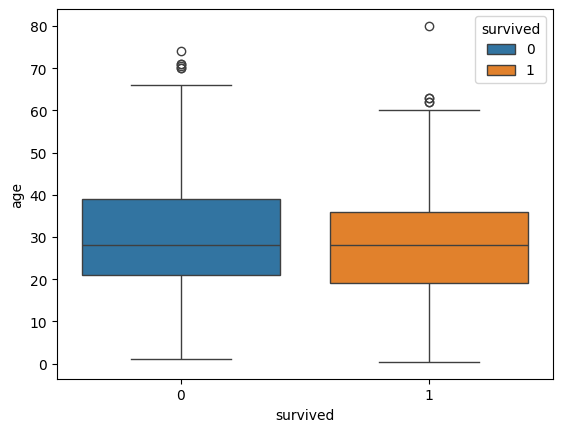

In [80]:
sns.boxplot(x="survived", y="age", data=df, hue=   "survived")

<Axes: xlabel='sibsp', ylabel='count'>

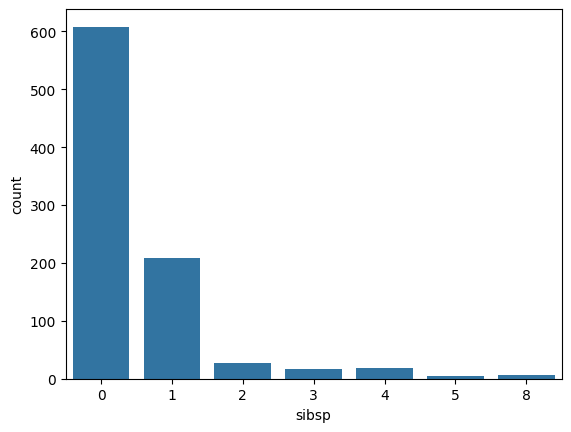

In [81]:
sns.countplot(x="sibsp", data=df)

<Axes: xlabel='sibsp', ylabel='count'>

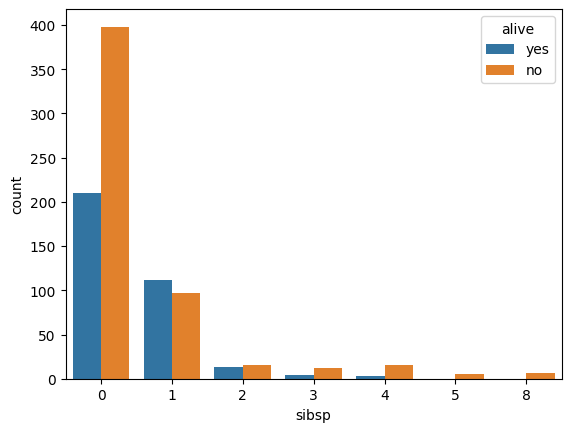

In [82]:
sns.countplot(x="sibsp", data=df, hue= "alive")

<Axes: xlabel='parch', ylabel='count'>

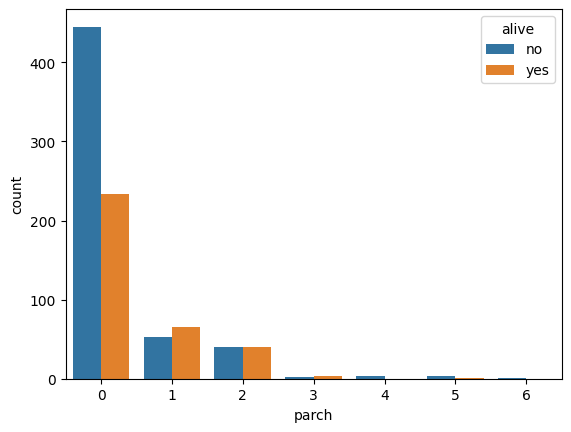

In [83]:
sns.countplot(x="parch", data=df, hue="alive")

<Axes: xlabel='survived', ylabel='fare'>

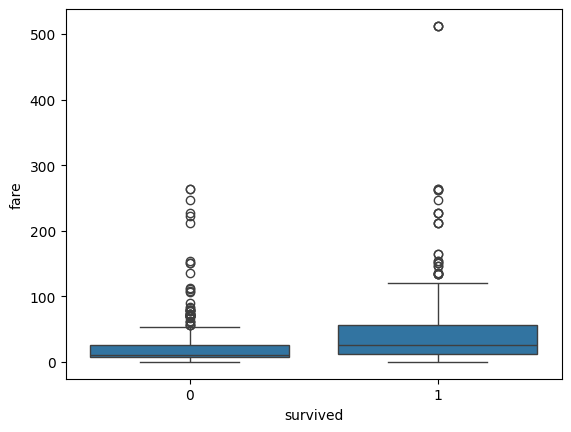

In [84]:
sns.boxplot(x="survived", y="fare", data=df)

In [85]:
df[df["fare"] > 400].index

Index([258, 679, 737], dtype='int64')

In [86]:
df.drop(df[df["fare"] > 400].index, inplace=True)

<Axes: xlabel='alive', ylabel='fare'>

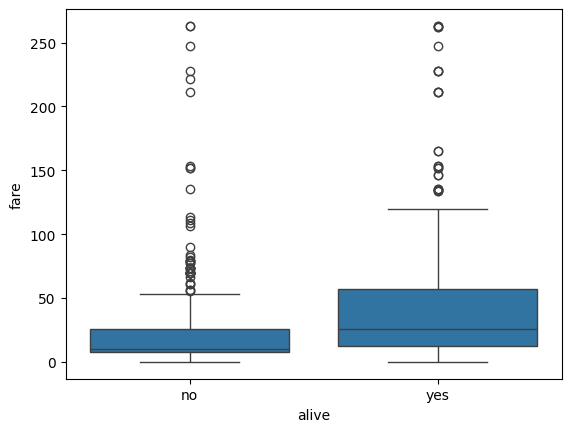

In [87]:
sns.boxplot(x="alive", y="fare", data=df)

<Axes: xlabel='embarked', ylabel='count'>

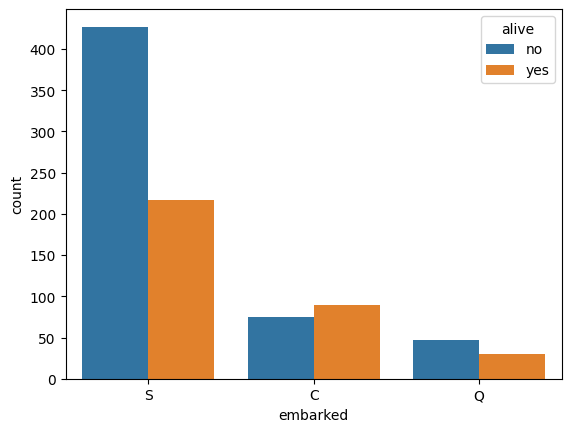

In [88]:
sns.countplot(x="embarked", data=df, hue="alive")

<Axes: xlabel='who', ylabel='count'>

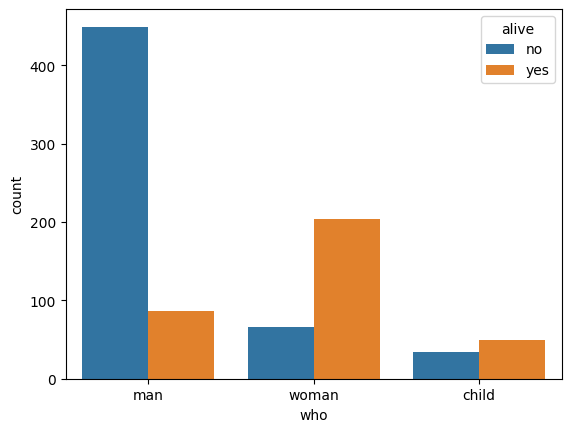

In [89]:
sns.countplot(x="who", data=df,hue="alive")

In [90]:
df[["survived", "pclass","age","sibsp","parch","fare"]].corr()

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.334068,-0.079472,-0.033395,0.082157,0.261742
pclass,-0.334068,1.000000,-0.368625,0.080937,0.018212,-0.604960
age,-0.079472,-0.368625,1.000000,-0.307639,-0.189194,0.100396
sibsp,-0.033395,0.080937,-0.307639,1.000000,0.415141,0.211816
parch,0.082157,0.018212,-0.189194,0.415141,1.000000,0.263910
fare,0.261742,-0.604960,0.100396,0.211816,0.263910,1.000000


<Axes: >

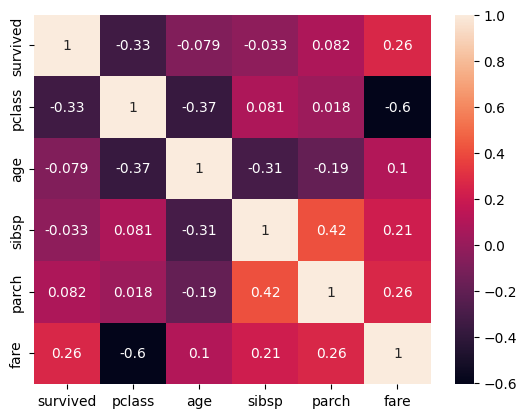

In [91]:
sns.heatmap(df[["survived", "pclass","age","sibsp","parch","fare"]].corr(), annot=True)